In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('generated_dataset_add.csv')
df.head()

,A,B,C,D
0,87,97,45,229
1,41,81,11,133
2,67,54,92,213
3,12,54,95,161
4,15,90,91,196


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       40 non-null     int64
 1   B       40 non-null     int64
 2   C       40 non-null     int64
 3   D       40 non-null     int64
dtypes: int64(4)
memory usage: 1.4 KB


In [5]:
df.describe()

,A,B,C,D
count,40.000000,40.00000,40.000000,40.000000
mean,37.800000,52.92500,48.950000,139.675000
std,27.927746,30.46931,32.590662,55.863105
min,0.000000,1.00000,0.000000,28.000000
25%,15.000000,30.75000,13.750000,103.750000
50%,31.500000,52.00000,50.500000,129.500000
75%,54.500000,80.25000,77.000000,178.750000
max,97.000000,99.00000,98.000000,237.000000


Text(0.5, 1.0, 'Scatter plot of A vs D')

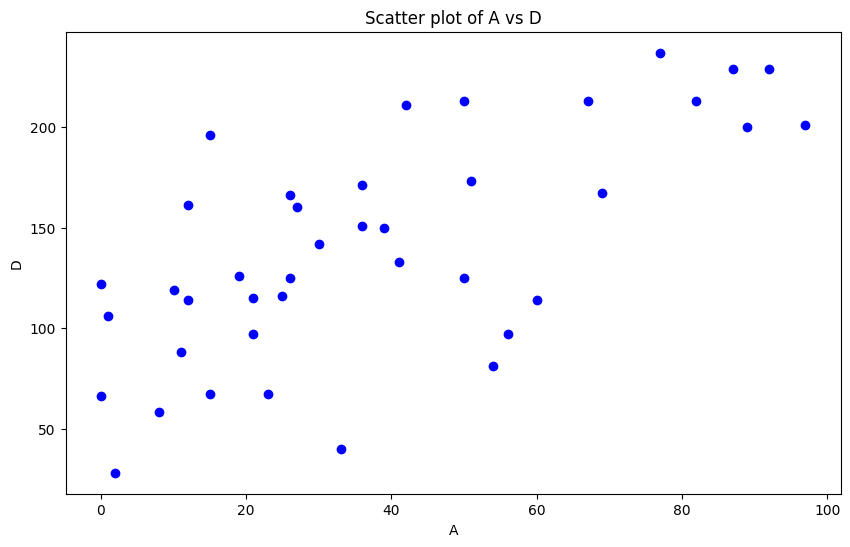

In [6]:
fig =  plt.figure(figsize=(10, 6))


plt.scatter(df['A'], df['D'], color='blue', label='A vs D')

plt.xlabel('A')
plt.ylabel('D')
plt.title('Scatter plot of A vs D')

Text(0.5, 1.0, 'Scatter plot of B vs D')

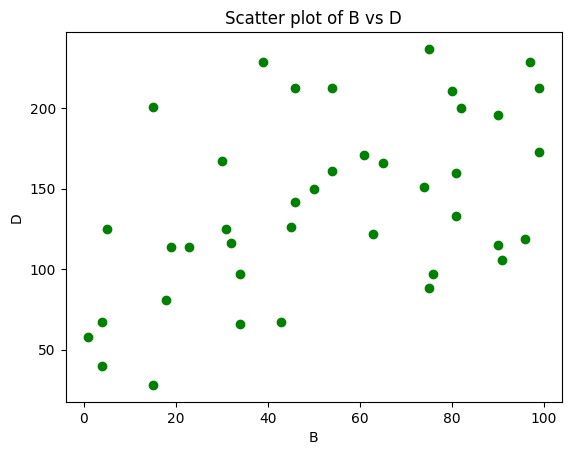

In [7]:
plt.scatter(df["B"], df["D"], color='green', label='B vs D')
plt.xlabel('B')
plt.ylabel('D')
plt.title('Scatter plot of B vs D')


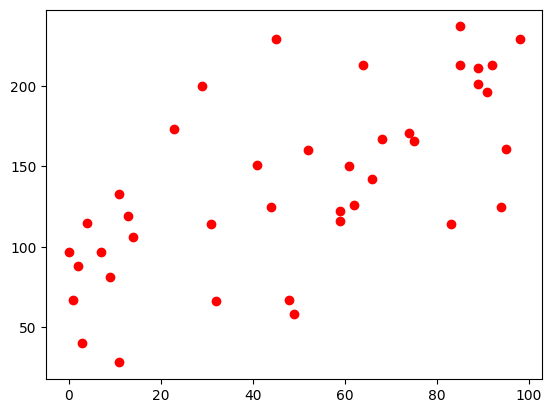

In [8]:

plt.scatter(df["C"], df["D"],color='red', label='C vs D')

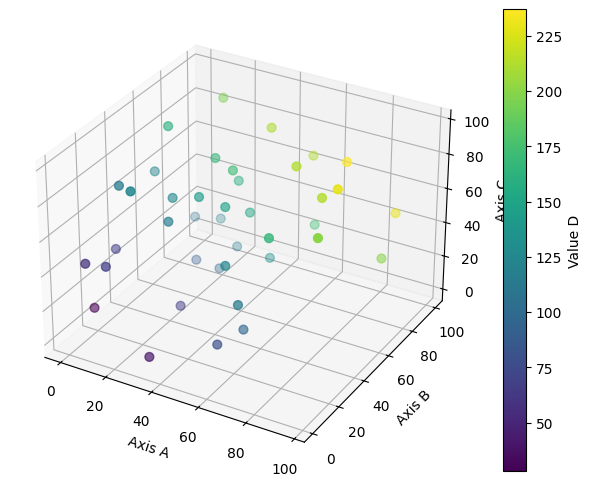

In [11]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

# Map A, B, C to axes, and D to the color gradient
scatter = ax.scatter(df["A"], df["B"], df["C"], c=df["D"], cmap="viridis", s=40)

# Add labels and colorbar
ax.set_xlabel("Axis A")
ax.set_ylabel("Axis B")
ax.set_zlabel("Axis C")
fig.colorbar(scatter, label="Value D")

plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [13]:
X_train, X_test, y_train, y_test = train_test_split(df[['A', 'B', 'C']], df['D'], test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((32, 3), (8, 3), (32,), (8,))

In [15]:
X_train.head(4)

,A,B,C
39,11,75,2
6,2,15,11
25,0,34,32
9,0,63,59


In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = lr.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
r2 = r2_score(y_test, y_pred)
r2

1.0

In [20]:
mae = mean_absolute_error(y_test, y_pred)

In [21]:
mse = mean_squared_error(y_test, y_pred)

In [22]:
rmse = np.sqrt(mse)

In [23]:
mae,mse,rmse

(1.4210854715202004e-14,
 3.534096855390133e-28,
 np.float64(1.879919374704706e-14))

/home/varsha/PracticePython/pracvenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


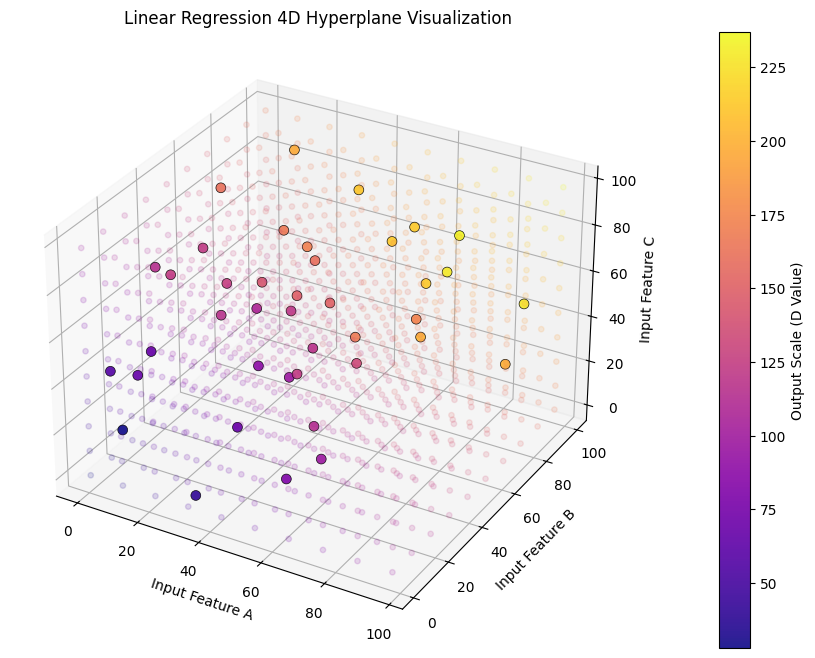

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize a native 3D canvas
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection="3d")

# 2. Scatter plot your ACTUAL data points
# Positioned by A, B, C; Color determined by actual D values
scatter_actual = ax.scatter(
    df["A"],
    df["B"],
    df["C"],
    c=df["D"],
    cmap="plasma",  # A bright color map for actual points
    s=50,
    edgecolor="black",
    linewidth=0.5,
    label="Actual Data",
    alpha=0.9,
)

# 3. Build a dense 3D prediction mesh background
# This fills the 3D space with tiny background points representing the model's prediction gradient
a_space = np.linspace(df["A"].min(), df["A"].max(), 10)
b_space = np.linspace(df["B"].min(), df["B"].max(), 10)
c_space = np.linspace(df["C"].min(), df["C"].max(), 10)

A_grid, B_grid, C_grid = np.meshgrid(a_space, b_space, c_space)

# Flatten the grid coordinates to pass to your model's prediction method
grid_flat = np.c_[A_grid.ravel(), B_grid.ravel(), C_grid.ravel()]
predicted_D_flat = lr.predict(grid_flat)

# 4. Scatter plot the MODEL's continuous prediction gradient
# We use a semi-transparent background marker to show the continuous "hyperplane" color shift
scatter_pred = ax.scatter(
    grid_flat[:, 0],
    grid_flat[:, 1],
    grid_flat[:, 2],
    c=predicted_D_flat,
    cmap="plasma",
    s=15,
    alpha=0.15,  # Kept faint so it looks like a colored volume haze
    marker="o",
)

# 5. Labeling and styling
ax.set_xlabel("Input Feature A")
ax.set_ylabel("Input Feature B")
ax.set_zlabel("Input Feature C")
ax.set_title("Linear Regression 4D Hyperplane Visualization")

# Separate color bars to compare target vs prediction mapping
cbar = fig.colorbar(scatter_actual, ax=ax, orientation="vertical", pad=0.1)
cbar.set_label("Output Scale (D Value)")

plt.show()

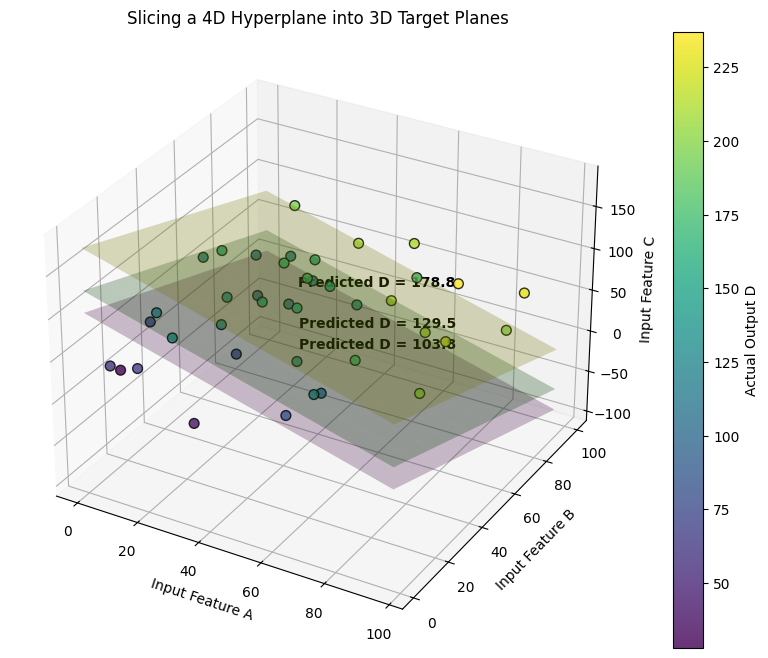

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize a native 3D canvas
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection="3d")

# 2. Plot your actual data points (A=X, B=Y, C=Z, Color=Output D)
scatter = ax.scatter(
    df["A"],
    df["B"],
    df["C"],
    c=df["D"],
    cmap="viridis",
    s=50,
    alpha=0.8,
    edgecolor="k",
    label="Actual Data",
)

# 3. Calculate 3 target values you want to isolate (e.g., Low, Medium, High Output)
# This finds the 25th, 50th, and 75th percentiles of your output column D
targets = np.percentile(df["D"], [25, 50, 75])
plane_colors = ["purple", "green", "yellow"]

# 4. Generate spatial grids for input features A and B
a_vals = np.linspace(df["A"].min(), df["A"].max(), 10)
b_vals = np.linspace(df["B"].min(), df["B"].max(), 10)
A_mesh, B_mesh = np.meshgrid(a_vals, b_vals)

# 5. Extract weights from your trained Linear Regression model (lr)
b0 = lr.intercept_
b1, b2, b3 = lr.coef_[0], lr.coef_[1], lr.coef_[2]

# 6. Slice the Hyperplane into flat 3D planes at specific target outputs
# Rearranging equation to solve for C: C = (D - b0 - b1*A - b2*B) / b3
for target_val, color in zip(targets, plane_colors):
    Z_plane = (target_val - b0 - (b1 * A_mesh) - (b2 * B_mesh)) / b3

    # Draw the flat plane inside your 3D input space
    ax.plot_surface(
        A_mesh,
        B_mesh,
        Z_plane,
        color=color,
        alpha=0.25,  # Make it transparent to see the dots inside
        linewidth=0,
    )
    # Add a text label next to each plane
    ax.text(
        df["A"].mean(),
        df["B"].mean(),
        Z_plane.mean(),
        f"Predicted D = {target_val:.1f}",
        color="black",
        weight="bold",
    )

# 7. Add Labels and Color Bar
ax.set_xlabel("Input Feature A")
ax.set_ylabel("Input Feature B")
ax.set_zlabel("Input Feature C")
ax.set_title("Slicing a 4D Hyperplane into 3D Target Planes")

fig.colorbar(scatter, label="Actual Output D")
plt.show()

In [27]:
import pickle

In [ ]:
# this means that we are saving the model to a file called 'model.pkl' in binary write mode
with open('model.pkl', 'wb') as file:
    pickle.dump(lr, file)

In [ ]:
# this means that we are loading the model from a file called 'model.pkl' in binary read mode
# why do we need to load the model? Because we want to use the trained model for making predictions on new data without retraining it every time. By saving the model to a file, we can easily load it later and use it for inference.
with open('model.pkl', 'rb') as file:
    lr = pickle.load(file)